In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned_master.csv', parse_dates=['order_purchase_timestamp'])

# keep only one row per customer per order
df_orders = df.drop_duplicates(subset=['customer_unique_id', 'order_id'])
print(df_orders.shape)

(96470, 31)


In [2]:
# get each customer's first purchase month (cohort)
df_orders['order_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

cohort_data = df_orders.groupby('customer_unique_id')['order_month'].min().reset_index()
cohort_data.columns = ['customer_unique_id', 'cohort_month']

# merge back
df_orders = df_orders.merge(cohort_data, on='customer_unique_id')

# calculate months since first purchase
df_orders['months_since_first'] = (df_orders['order_month'] - df_orders['cohort_month']).apply(lambda x: x.n)

print(df_orders[['customer_unique_id', 'order_month', 'cohort_month', 'months_since_first']].head(10))

                 customer_unique_id order_month cohort_month  \
0  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09   
1  af07308b275d755c9edb36a90c618231     2018-07      2018-07   
2  3a653a41f6f9fc3d2a113cf8398680e8     2018-08      2018-08   
3  7c142cf63193a1473d2e66489a9ae977     2017-11      2017-11   
4  72632f0f9dd73dfee390c9b22eb56dd6     2018-02      2018-02   
5  80bb27c7c16e8f973207a5086ab329e2     2017-07      2017-07   
6  932afa1e708222e5821dac9cd5db4cae     2017-05      2017-05   
7  39382392765b6dc74812866ee5ee92a7     2017-01      2017-01   
8  299905e3934e9e181bfb2e164dd4b4f8     2017-07      2017-07   
9  f2a85dec752b8517b5e58a06ff3cd937     2017-05      2017-05   

   months_since_first  
0                   1  
1                   0  
2                   0  
3                   0  
4                   0  
5                   0  
6                   0  
7                   0  
8                   0  
9                   0  


In [3]:
# build cohort table
cohort_table = df_orders.groupby(['cohort_month', 'months_since_first'])['customer_unique_id'].nunique().reset_index()
cohort_table.columns = ['cohort_month', 'months_since_first', 'customers']

# pivot into matrix
cohort_pivot = cohort_table.pivot(index='cohort_month', columns='months_since_first', values='customers')

# convert to retention % (divide each row by its month 0 value)
cohort_pct = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3) * 100

print(cohort_pct.iloc[:5, :6])

months_since_first      0      1    2    3    4    5
cohort_month                                        
2016-09             100.0    NaN  NaN  NaN  NaN  NaN
2016-10             100.0    NaN  NaN  NaN  NaN  NaN
2016-12             100.0  100.0  NaN  NaN  NaN  NaN
2017-01             100.0    0.3  0.3  0.1  0.4  0.1
2017-02             100.0    0.2  0.3  0.1  0.4  0.1


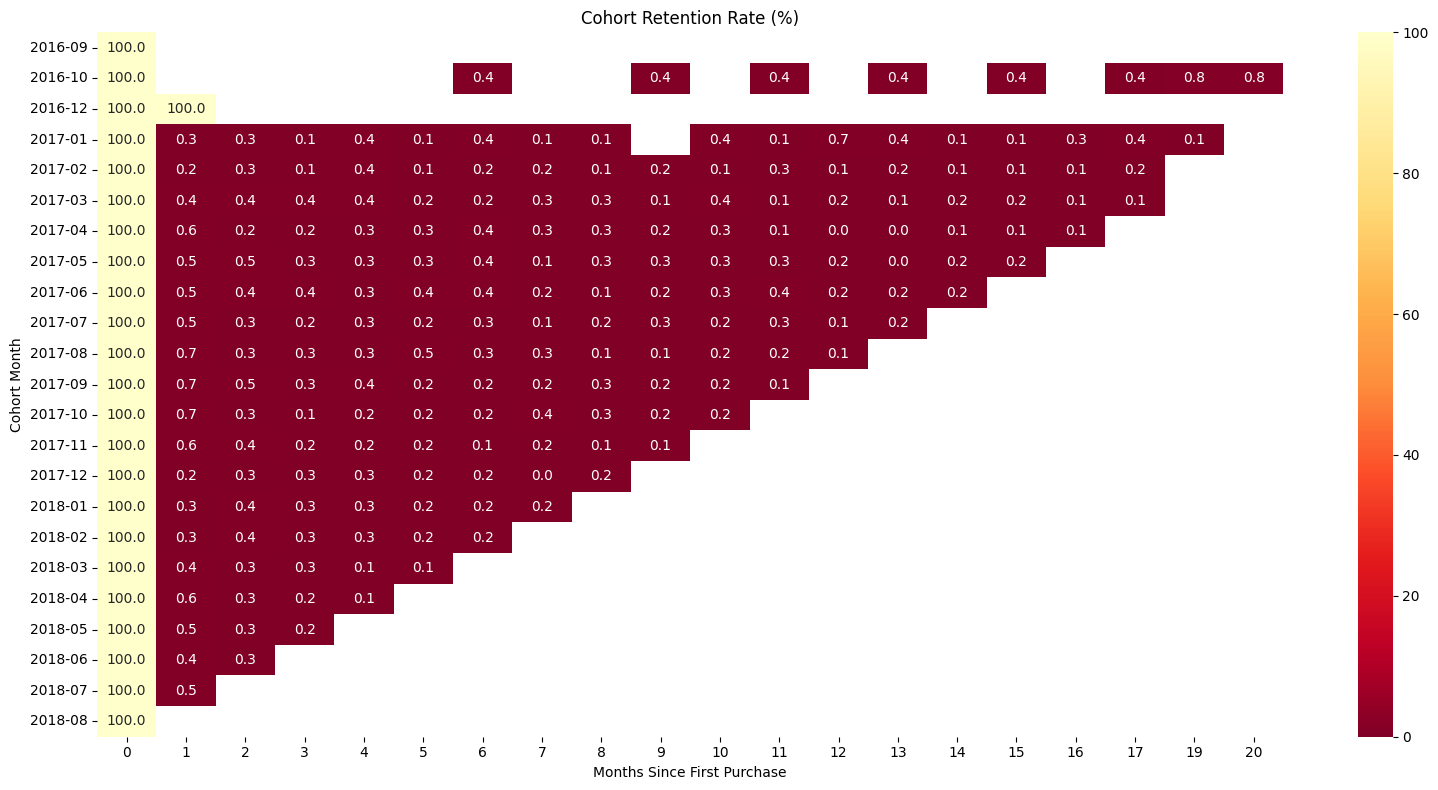

In [4]:
plt.figure(figsize=(16, 8))
sns.heatmap(cohort_pct, 
            annot=True, 
            fmt='.1f',
            cmap='YlOrRd_r',
            mask=cohort_pct.isnull())

plt.title('Cohort Retention Rate (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('../images/cohort_heatmap.png')
plt.show()